# NIST CSF SMB IR Gap Detection Bot
## Ensuring post-incident response meetings have no gaps under the NIST CSF SMB (Small Business Guide)
This project provides small businesses with a tool to input meeting transcripts and generate documentation identifying which post-breach incident response topics, aligned to the NIST CSF SMB framework, were discussed. The resulting report highlights both strengths and potential gaps in incident response posture.

## Train and Test Data
Run the code below to train the model and evaluate its performance using an 80/20 train-test split.

In [3]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from IPython.display import display, HTML

#Read in training dataset
df = pd.read_csv('https://raw.githubusercontent.com/MarkoGutierro/Incident-Response-Bot/refs/heads/main/1000rows.csv', header=None)
#df.head() #Uncomment to see if dataset was read in properly

#Split the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(df[1], df[0], test_size=0.2, random_state=13)

#Convert labels to numbers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

#Convert text to numbers
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#Create Logictic Regression Model, fit it with training set
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_vec, y_train_enc)

#Run test
y_pred = model.predict(X_test_vec)

#Print test results
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    RS.AN-03       0.93      0.90      0.91        41
       RS.CO       0.97      0.93      0.95        30
    RS.MA-03       0.97      0.97      0.97        37
    RS.MI-01       0.89      0.94      0.91        34
    RS.MI-02       0.93      0.93      0.93        58

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



**Run the below code only if you want to see how the bot evaluated all 200 data points individually.**

In [ ]:
for i in range(len(X_test)):
    print("Text:", X_test.iloc[i])
    print("Predicted:", le.inverse_transform([y_pred[i]])[0])
    print("Actual:", le.inverse_transform([y_test_enc[i]])[0])
    print("---")

## Visualizations
Run the code below to generate the following visuals based on the test data:
1. A bar chart showing the F1 Score by category.
2. A pie chart representing raw accuracy.
3. A table displaying the first 10 analyzed rows and the model's correctness.

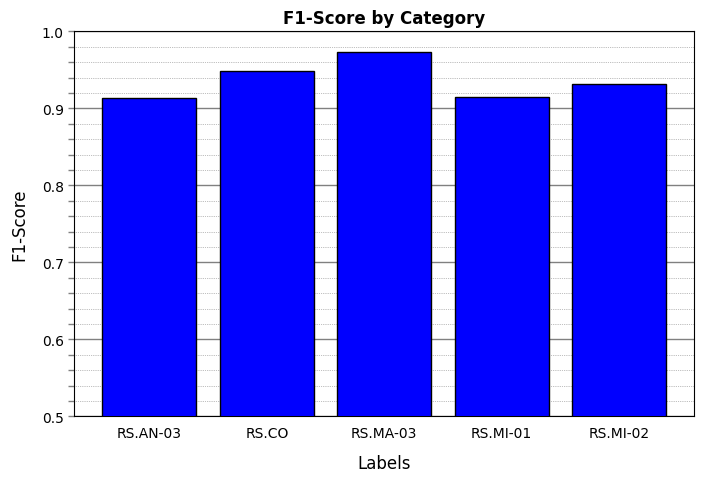

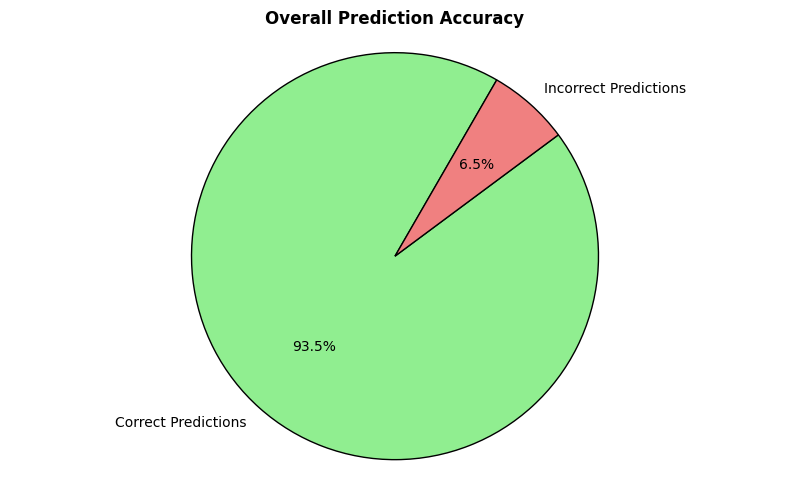

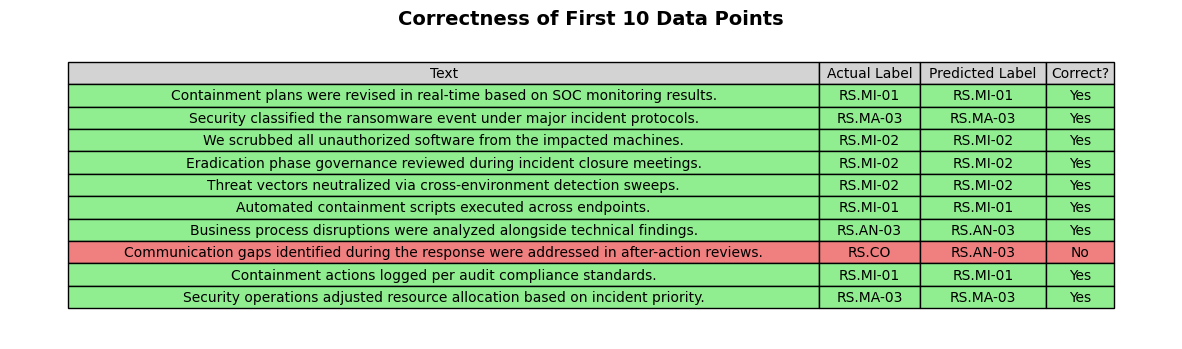

In [ ]:
# Run test if needed
y_pred = model.predict(X_test_vec)

# ---- F1-Score Bar Chart ----

# Extract F1-scores for each class from the classification report
report = classification_report(y_test_enc, y_pred, target_names=le.classes_, output_dict=True)
f1_labels = list(report.keys())[:-3]
f1_scores = [report[label]['f1-score'] for label in f1_labels]

# Create a bar chart to visualize F1-scores for each label
plt.figure(figsize=(8, 5))
plt.bar(f1_labels, f1_scores)
plt.xlabel('Labels')
plt.ylabel('F1-Score')
plt.title('F1-Score by Category', fontweight='bold')

# Set y-axis limits (focus on scores from 0.5 to 1)
plt.ylim(0.5, 1)

# Create the bar chart with blue bars and black borders
bars = plt.bar(f1_labels, f1_scores, zorder=3, color='blue', edgecolor='black', linewidth=1)

# Customize y-axis ticks and gridlines
plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.minorticks_on()
plt.tick_params(axis='y', which='major', length=4, width=1, colors='gray', grid_color='gray', grid_linewidth=1, labelcolor='black')
plt.tick_params(axis='y', which='minor', length=4, width=1, colors='gray', grid_color='gray', grid_linewidth=0.5)
plt.tick_params(axis='x', which='both', bottom=False)  # Remove x-axis bottom ticks

# Customize gridlines
plt.grid(axis='y', which='major', linestyle='-', linewidth=1, zorder=1)
plt.grid(axis='y', which='minor', linestyle=':', linewidth=0.5, zorder=1)

# Set x and y axis labels with larger font for emphasis and added padding for more space from the chart
plt.xlabel('Labels', fontsize=12, labelpad=10)
plt.ylabel('F1-Score', fontsize=12, labelpad=10)

#Display bar graph
plt.show()

# Add vertical space between plots
print("\n" * 2)

# ---- Prediction Accuracy Pie Chart ----

# Calculate the number of correct and incorrect predictions
correct = (y_pred == y_test_enc).sum()
incorrect = (y_pred != y_test_enc).sum()

# Create a pie chart to visualize the distribution of correct vs incorrect predictions
plt.figure(figsize=(8, 5))
plt.pie(
    [correct, incorrect],
    labels=['Correct Predictions', 'Incorrect Predictions'],
    autopct='%1.1f%%',
    startangle=60,
    colors=['lightgreen', 'lightcoral'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
plt.title('Overall Prediction Accuracy', fontweight='bold')
plt.axis('equal')
plt.tight_layout()

#Display pie chart
plt.show()

# Add vertical space between plots
print("\n" * 2)

# ---- Text Table Visualization ----

# Prepare table data with text, actual labels, predicted labels, and correctness (Yes/No)
table_data = [
    [row['Text'], row['Actual Label'], row['Predicted Label'], 'Yes' if row['Correct'] else 'No']
    for _, row in sample_table.iterrows()
]

# Create plot and remove unneeded axes
fig, ax = plt.subplots(figsize=(15, len(table_data) * 0.4))
ax.axis('off')

# Add a title to the chart
plt.title('Correctness of First 10 Data Points', fontsize=14, pad=5, fontweight='bold')

# Create a table chart to visualize correctness for first 10 model guesses
table = ax.table(
    cellText=table_data,
    colLabels=['Text', 'Actual Label', 'Predicted Label', 'Correct?'],
    cellLoc='center',
    loc='center',
    bbox=[0.05, 0.1, 0.9, 0.8]
)

# Set table font-size and scale row height for proper spacing
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Wrap long text inside cells
for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center', wrap=True)

# Adjust column widths to fit content, especially for the Text column
table.auto_set_column_width([0, 1, 2, 3])

# Highlight correct/incorrect rows
for i, row in enumerate(table_data, start=1):
    color = 'lightgreen' if row[3] == 'Yes' else 'lightcoral'
    for j in range(len(row)):
        table[(i, j)].set_facecolor(color)

# Style the first row with light grey
for j in range(len(table_data[0])):
    table[(0, j)].set_facecolor('lightgrey')

# Display table chart
plt.show()

## Interactive Query
Run the code below to interact with the bot. Paste meeting samples to receive predicted labels, or input custom sentences. Example text is provided at the bottom of this section for testing.


In [ ]:
import re  # Allow splitting text using punctuation as delimiters

# Function to handle multi-line input and predict by sentence
def interactive_query_multi(user_input, threshold=0.35):
    # Define variables
    all_labels = list(le.classes_) + ['Not Relevant'] # List of all labels
    counts = {label: 0 for label in all_labels} # Dictionary counting frequency of labels in text
    sentences_by_label = {label: [] for label in all_labels} # Dictionary assigning sentences to labels

    # Split the input into sentences based on punctuation (. ! ?)
    sentences = re.split(r'[.!?]', user_input)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Assign labels to sentences and count the frequency of labels
    for sentence in sentences:
        vec = vectorizer.transform([sentence])
        proba = model.predict_proba(vec).max()
        if proba < threshold:
            label = 'Not Relevant'
        else:
            pred = model.predict(vec)
            label = le.inverse_transform(pred)[0]
        counts[label] += 1
        sentences_by_label[label].append(sentence)

    # Output header
    print('\n' + '=' * 24)
    print('\033[1mFORMATTED MEETING OUTPUT\033[0m')
    print('=' * 24 + '\n')

    # Display label frequency and missing category warnings
    print('\033[1mFrequency of Labels\033[0m')
    for label in all_labels:
        if counts[label] == 0 and label != 'Not Relevant':
            print(f'{label}: {counts[label]} — Gap detected, make sure this area is addressed')
        else:
            print(f'{label}: {counts[label]}')
    print()

    # Print sentences grouped by label
    for label in all_labels:
        print(f'\033[1m=== {label} ===\033[0m')
        for sent in sentences_by_label[label]:
            print(sent)
        print()

# Prompt user to paste multi-line input
print("Paste your text below, then press Enter when you're done::")

# Collect multi-line input from the user
user_input = input()
print()

# Call the function to process the input
interactive_query_multi(user_input)

Paste your text (multiple lines allowed), then press Enter when done:


 The security team analyzed suspicious traffic patterns identified during routine monitoring. Logs were reviewed to confirm the timeline of the intrusion. Firewall rules were updated to block malicious IP addresses immediately. Compromised user accounts were disabled to prevent further damage. Security patches were installed across all affected systems. Infected devices were moved to a secure quarantine network. Incident updates were shared with executive leadership. Law enforcement was notified about the security breach.  I went to the gym to lift weights this morning. My neighbor is hosting a barbecue this weekend. We painted the guest bedroom blue yesterday. I watched a movie about ancient civilizations last night. I got a coffee from the new cafe on 7th Street. The security awareness team conducted a phishing training session for employees. A new endpoint protection policy was announced to all staff members.




FORMATTED MEETING OUTPUT

Frequency of Labels
RS.AN-03: 2
RS.CO: 2
RS.MA-03: 0 — Gap detected, make sure this area is addressed
RS.MI-01: 3
RS.MI-02: 1
Not Relevant: 7

=== RS.AN-03 ===
The security team analyzed suspicious traffic patterns identified during routine monitoring
Logs were reviewed to confirm the timeline of the intrusion

=== RS.CO ===
Incident updates were shared with executive leadership
Law enforcement was notified about the security breach

=== RS.MA-03 ===

=== RS.MI-01 ===
Firewall rules were updated to block malicious IP addresses immediately
Compromised user accounts were disabled to prevent further damage
Infected devices were moved to a secure quarantine network

=== RS.MI-02 ===
Security patches were installed across all affected systems

=== Not Relevant ===
I went to the gym to lift weights this morning
My neighbor is hosting a barbecue this weekend
We painted the guest bedroom blue yesterday
I watched a movie about ancient civilizations last night
I got a

**The below is example text that can be pasted into the bot to test how it processes data.**

The security team analyzed suspicious traffic patterns identified during routine monitoring.
Logs were reviewed to confirm the timeline of the intrusion.
Firewall rules were updated to block malicious IP addresses immediately.
Compromised user accounts were disabled to prevent further damage.
Security patches were installed across all affected systems.
Infected devices were moved to a secure quarantine network.
Incident updates were shared with executive leadership.
Law enforcement was notified about the security breach.

I went to the gym to lift weights this morning.
My neighbor is hosting a barbecue this weekend.
We painted the guest bedroom blue yesterday.
I watched a movie about ancient civilizations last night.
I got a coffee from the new cafe on 7th Street.
The security awareness team conducted a phishing training session for employees.
A new endpoint protection policy was announced to all staff members.

## Final Considerations
This section outlines security features and ongoing monitoring and maintenance strategies.

### Security Features
This project processes text entirely in-memory and does not store or log any data. The text is held temporarily during processing and cleared immediately after use. This ensures no sensitive data is retained or exposed. By avoiding persistent storage, the system minimizes the risk of unauthorized access or data leaks. This approach adheres to best practices for securely handling sensitive information.

### Monitoring and Maintenance Plan
To maintain ongoing performance and reliability, the following measures are recommended:
- Monitor model drift by tracking prediction accuracy over time, with retraining triggered if significant performance degradation is detected due to changes in real-world data.
- Log incorrect predictions to identify recurring failure patterns.
- Retrain the model periodically or following major shifts in incident response practices, emerging threat types, or regulatory changes.
- Conduct periodic bias reviews to ensure the model remains fair and does not disproportionately misclassify certain categories.